**Sales Prediction Using Python**

AI-powered Sales Prediction project using Machine Learning, Python, and Streamlit to predict product sales based on TV, Radio, and Newspaper advertising budgets with interactive visualizations and real-time predictions.

**Step 1: Import Libraries**

In [2]:
import pandas as pd #file read and data manipulation
import numpy as np #for numeric calculations
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for advance data visualization
from sklearn.model_selection import train_test_split #for spliting data into train and test sets
from sklearn.linear_model import LinearRegression #for numeric value prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #for evaluating model performance
import joblib #to save and load model

**Step 2: Load Dataset**

In [3]:
df = pd.read_csv('Advertising.csv')

**Step 3: Create copy of dataset**

In [4]:
df_copy = df.copy()

**Step 4: Basic EDA**

In [5]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
print("Last 5 rows: ")
df.tail()

Last 5 rows: 


,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [7]:
print("Shape of dataset: ")
df.shape

Shape of dataset: 


(200, 5)

In [8]:
print("Basic Information regarding dataset: ")
df.info()

Basic Information regarding dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [9]:
print("Columns related information: ")
df.columns

Columns related information: 


Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [10]:
print("Statistica Summary: ")
df.describe()

Statistica Summary: 


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


**Step 4: Checking for missing values**

In [11]:
df_copy.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

## Insight:

No missing values in dataset so the data is already in clean state.

**Step 5: Data Visualization**

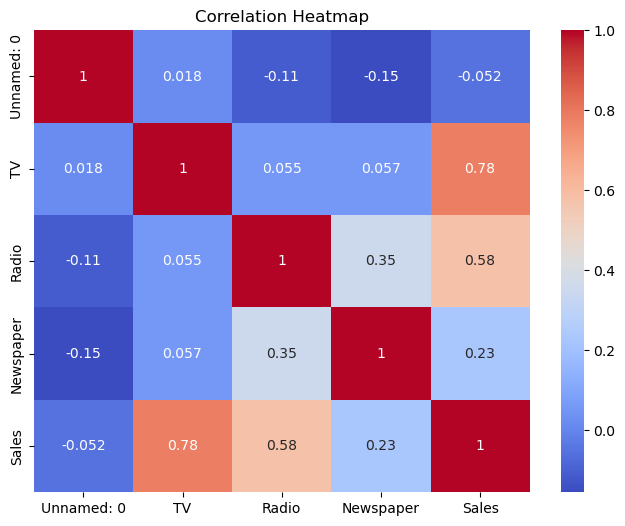

In [12]:
plt.figure(figsize = (8,6))
sns.heatmap(df_copy.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation_Heatmap.png')
plt.show()

## Insight:

1. TV advertisement strongly affects sales
2. Radio also affects sales
3. Newspaper has lower impact

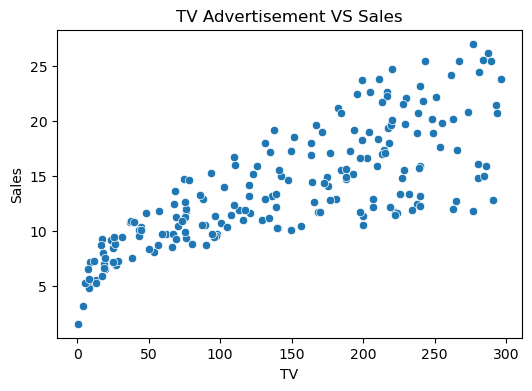

In [13]:
plt.figure(figsize = (6,4))
sns.scatterplot(x = 'TV', y = 'Sales', data = df_copy)
plt.title('TV Advertisement VS Sales')
plt.savefig('TV_VS_Sales.png')
plt.show()

## Insight:

1. Higher TV ads usually increase sales
2. Strong positive relationship exists

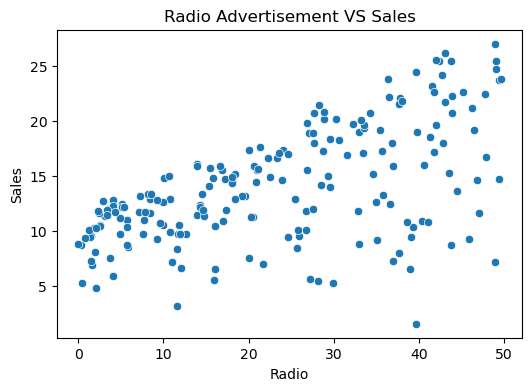

In [14]:
plt.figure(figsize = (6,4))
sns.scatterplot(x = 'Radio', y = 'Sales', data = df_copy)
plt.title('Radio Advertisement VS Sales')
plt.savefig('Radio_VS_Sales.png')
plt.show()

## Insights:

1. Radio ads also impact sales

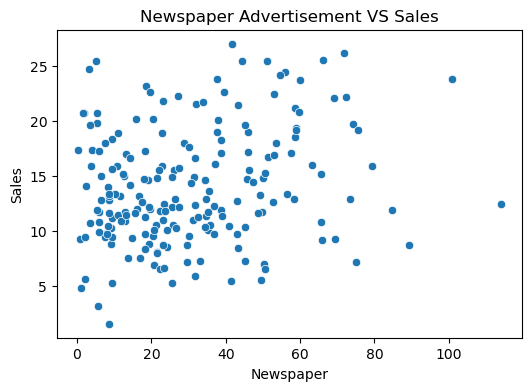

In [15]:
plt.figure(figsize = (6,4))
sns.scatterplot(x = 'Newspaper', y = 'Sales', data = df_copy)
plt.title('Newspaper Advertisement VS Sales')
plt.savefig('Newspaper_VS_Sales.png')
plt.show()

## Insights:

1. Newspaper ads have weaker impact on sales.

**Step 6: Select Features and Target**

In [16]:
x = df_copy[['TV', 'Radio', 'Newspaper']]
y = df_copy['Sales']

x -> Input Features


y -> Output Features

**Step 7: Split Dataset**

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [18]:
print(f'Total Samples: {len(df_copy)}')
print(f'Training Samples: {len(x_train)}')
print(f'Testing Samples: {len(x_test)}')

Total Samples: 200
Training Samples: 160
Testing Samples: 40


we will use 20% of data for test set and rest for training model and we have also use random state so that it keeps split same every run so overall it helps to test model on unseen data. 

**Step 8: Model training**

In [19]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model Learns Patterns and relationships between input features and sales.

In [20]:
print('Model Training Completed')

Model Training Completed


**Step 9: Model Prediction**

In [21]:
y_prediction = model.predict(x_test)

model predicts sales using testing data.

**Step 10: Evaluating Model**

In [22]:
mae = mean_absolute_error(y_test, y_prediction)

Calculates average prediction error.

Lower MAE = better model.

In [23]:
mse = mean_squared_error(y_test, y_prediction)

Calculates squared prediction error.

Lower MSE = better model

In [24]:
r2 = r2_score(y_test, y_prediction)

Calculates model accuracy


Closer to 1 = excellent accuracy

In [25]:
print("MAE: ", mae)
print("MSE: ", mse)
print("R2 Score: ", r2)

MAE:  1.4607567168117606
MSE:  3.1740973539761055
R2 Score:  0.899438024100912


In [26]:
print(f'Accuracy: {r2 * 100} %')

Accuracy: 89.9438024100912 %


## Insight:

1. Low error means good prediction
2. High R2 score means strong accuracy

**Step 11: Saving Model**

In [28]:
joblib.dump(model, 'sales_model.pkl')

['sales_model.pkl']

Saves trained model.

**Step 12: Important Insights**

1. TV advertising has the highest impact on sales.
2. Increasing ad budget usually increases sales.
3. Radio ads also help improve sales performance.
4. Newspaper ads have the lowest effect on sales.
5. Most sales values are between medium to high range.
6. Features show a positive relationship with sales.
7. Linear Regression performs well on this dataset.
8. Higher TV and Radio spending gives better predictions.